## DATA COLLECTION


In [1]:
from bs4 import BeautifulSoup
import requests
import pandas as pd
import time

In [2]:
#OpenAQ
header = {
    "X-API-Key": "03114727b878221d6ad1d327ba6255c8caece790041cef7de911cde75955d31d",
    "accept": "application/json"
}
# Use bbox (bounding box) for Delhi instead of city name
# Delhi bounding box: roughly 28.4 to 28.9 N, 76.8 to 77.4 E
res = requests.get(
    "https://api.openaq.org/v3/locations",
    headers=header,
    params={
        "bbox": "76.8,28.4,77.4,28.9",
        "limit": 100
    }
)
delhi_data = res.json()
print(res.status_code)
print(f"Total stations found: {delhi_data['meta']['found']}") #meta is like a summary page 

# Print just the names cleanly
for loc in delhi_data['results']:
    print(loc['id'], "-", loc['name'])

200
Total stations found: 95
13 - Delhi Technological University, Delhi - CPCB
15 - IGI Airport
16 - Civil Lines
17 - R K Puram, Delhi - DPCC
50 - Punjabi Bagh, Delhi - DPCC
103 - Income Tax Office, Delhi - CPCB
235 - Anand Vihar, New Delhi - DPCC
236 - Mandir Marg, Delhi - DPCC
301 - Vikas Sadan, Gurugram - HSPCB
431 - IHBAS, Delhi - CPCB
2503 - Shadipur, Delhi - CPCB
2587 - Sector16A, Faridabad - HSPCB
2597 - US Diplomatic Post: New Delhi
5404 - Pusa, Delhi - IMD
5509 - Anand Vihar, Delhi - DPCC
5540 - Punjabi Bagh, Delhi - DPCC
5541 - Burari Crossing, New Delhi - IMD
5570 - Aya Nagar, New Delhi - IMD
5581 - Pusa, New Delhi - IMD
5586 - Sirifort, Delhi - CPCB
5598 - Sector - 125, Noida, UP - UPPCB
5610 - North Campus, DU, Delhi - IMD
5613 - ITO, New Delhi - CPCB
5616 - Sector - 62, Noida, UP - IMD
5617 - Sector- 16A, Faridabad - HSPCB
5622 - NSIT Dwarka, Delhi - CPCB
5626 - DTU, New Delhi - CPCB
5627 - CRRI Mathura Road, New Delhi - IMD
5630 - Shadipur, Delhi - CPCB
5634 - Lodhi Road

In [3]:
delhi_data["results"][0]

{'id': 13,
 'name': 'Delhi Technological University, Delhi - CPCB',
 'locality': None,
 'timezone': 'Asia/Kolkata',
 'country': {'id': 9, 'code': 'IN', 'name': 'India'},
 'owner': {'id': 4, 'name': 'Unknown Governmental Organization'},
 'provider': {'id': 168, 'name': 'CPCB'},
 'isMobile': False,
 'isMonitor': True,
 'instruments': [{'id': 2, 'name': 'Government Monitor'}],
 'sensors': [{'id': 13866,
   'name': 'no2 µg/m³',
   'parameter': {'id': 5,
    'name': 'no2',
    'units': 'µg/m³',
    'displayName': 'NO₂ mass'}},
  {'id': 24,
   'name': 'o3 µg/m³',
   'parameter': {'id': 3,
    'name': 'o3',
    'units': 'µg/m³',
    'displayName': 'O₃ mass'}},
  {'id': 13864,
   'name': 'pm25 µg/m³',
   'parameter': {'id': 2,
    'name': 'pm25',
    'units': 'µg/m³',
    'displayName': 'PM2.5'}}],
 'coordinates': {'latitude': 28.744, 'longitude': 77.12},
 'licenses': None,
 'bounds': [77.12, 28.744, 77.12, 28.744],
 'distance': None,
 'datetimeFirst': {'utc': '2016-11-02T19:00:00Z',
  'local'

In [4]:
#print datetimeFirst and datetimeLast to check the inactive stations
for loc in delhi_data["results"]:
    print(f"id:{loc["id"]}  -  name:{loc["name"]} - datetimeLast:{loc["datetimeLast"]}")

id:13  -  name:Delhi Technological University, Delhi - CPCB - datetimeLast:{'utc': '2018-02-22T04:00:00Z', 'local': '2018-02-22T09:30:00+05:30'}
id:15  -  name:IGI Airport - datetimeLast:None
id:16  -  name:Civil Lines - datetimeLast:None
id:17  -  name:R K Puram, Delhi - DPCC - datetimeLast:{'utc': '2026-03-02T02:30:00Z', 'local': '2026-03-02T08:00:00+05:30'}
id:50  -  name:Punjabi Bagh, Delhi - DPCC - datetimeLast:{'utc': '2026-03-02T02:30:00Z', 'local': '2026-03-02T08:00:00+05:30'}
id:103  -  name:Income Tax Office, Delhi - CPCB - datetimeLast:{'utc': '2018-02-22T03:45:00Z', 'local': '2018-02-22T09:15:00+05:30'}
id:235  -  name:Anand Vihar, New Delhi - DPCC - datetimeLast:{'utc': '2026-03-02T02:30:00Z', 'local': '2026-03-02T08:00:00+05:30'}
id:236  -  name:Mandir Marg, Delhi - DPCC - datetimeLast:{'utc': '2018-02-21T21:15:00Z', 'local': '2018-02-22T02:45:00+05:30'}
id:301  -  name:Vikas Sadan, Gurugram - HSPCB - datetimeLast:{'utc': '2026-03-02T02:00:00Z', 'local': '2026-03-02T07:30

In [5]:
#checking active stations
active_stations=[]
for loc in delhi_data["results"]:
    if loc["datetimeLast"] is not None:
        last_date=loc["datetimeLast"]["utc"][:10]
        if last_date >= "2025-01-01":
            active_stations.append({
                "id":loc["id"],
                "name":loc["name"],
                "latitude":loc["coordinates"]["latitude"],
                "longitude":loc["coordinates"]["longitude"],
                "datetimeLast":last_date
            })
print(f"Active stations: {len(active_stations)}")
for s in active_stations:
    print(s)            

Active stations: 60
{'id': 17, 'name': 'R K Puram, Delhi - DPCC', 'latitude': 28.563262, 'longitude': 77.186937, 'datetimeLast': '2026-03-02'}
{'id': 50, 'name': 'Punjabi Bagh, Delhi - DPCC', 'latitude': 28.674045, 'longitude': 77.131023, 'datetimeLast': '2026-03-02'}
{'id': 235, 'name': 'Anand Vihar, New Delhi - DPCC', 'latitude': 28.646835, 'longitude': 77.316032, 'datetimeLast': '2026-03-02'}
{'id': 301, 'name': 'Vikas Sadan, Gurugram - HSPCB', 'latitude': 28.4501238, 'longitude': 77.0263051, 'datetimeLast': '2026-03-02'}
{'id': 5404, 'name': 'Pusa, Delhi - IMD', 'latitude': 28.639645, 'longitude': 77.146263, 'datetimeLast': '2026-03-02'}
{'id': 5541, 'name': 'Burari Crossing, New Delhi - IMD', 'latitude': 28.7256504, 'longitude': 77.2011573, 'datetimeLast': '2026-03-02'}
{'id': 5570, 'name': 'Aya Nagar, New Delhi - IMD', 'latitude': 28.474261, 'longitude': 77.131606, 'datetimeLast': '2026-03-02'}
{'id': 5586, 'name': 'Sirifort, Delhi - CPCB', 'latitude': 28.5504249, 'longitude': 77

In [6]:
#converting it into dataframe
stations_df=pd.DataFrame(active_stations)
stations_df.head()
stations_df.shape

(60, 5)

In [7]:
res = requests.get(
    "https://api.openaq.org/v3/locations/17/sensors",
    headers=header
)

sensors = res.json()
for sensor in sensors["results"]:
    if sensor["datetimeFirst"]["utc"][:10]>="2025-01-01":
        print(sensor["id"], "-", sensor["name"])

12234783 - no ppb
12234785 - o3 µg/m³
12234787 - pm25 µg/m³
12234784 - no2 ppb
12234786 - pm10 µg/m³
12234782 - co ppb
12234790 - temperature c
12234788 - relativehumidity %
12234789 - so2 ppb
14340715 - wind_speed m/s
14340714 - wind_direction deg
14340713 - nox ppb


In [8]:
res = requests.get(
    "https://api.openaq.org/v3/sensors/12234787/measurements",
    headers=header,
    params={
        "date_from": "2025-01-01",
        "date_to": "2026-02-27",  # today
        "limit": 1000
    }
)
measurements = res.json()
print(measurements["meta"])
print(measurements["results"][0])  # look at first reading

{'name': 'openaq-api', 'website': '/', 'page': 1, 'limit': 1000, 'found': '>1000'}
{'value': 123.0, 'flagInfo': {'hasFlags': False}, 'parameter': {'id': 2, 'name': 'pm25', 'units': 'µg/m³', 'displayName': None}, 'period': {'label': 'raw', 'interval': '00:15:00', 'datetimeFrom': {'utc': '2025-02-18T20:00:00Z', 'local': '2025-02-19T01:30:00+05:30'}, 'datetimeTo': {'utc': '2025-02-18T20:15:00Z', 'local': '2025-02-19T01:45:00+05:30'}}, 'coordinates': None, 'summary': None, 'coverage': {'expectedCount': 1, 'expectedInterval': '00:15:00', 'observedCount': 1, 'observedInterval': '00:15:00', 'percentComplete': 100.0, 'percentCoverage': 100.0, 'datetimeFrom': {'utc': '2025-02-18T20:00:00Z', 'local': '2025-02-19T01:30:00+05:30'}, 'datetimeTo': {'utc': '2025-02-18T20:15:00Z', 'local': '2025-02-19T01:45:00+05:30'}}}


In [9]:
# Try ITO station - find its ID from stations_df first
print(stations_df[stations_df['name'].str.contains('ITO')])
res = requests.get(
    "https://api.openaq.org/v3/locations/5613/sensors",
    headers=header
)

sensors = res.json()
for sensor in sensors["results"]:
    if sensor["datetimeFirst"]["utc"][:10]>="2025-01-01":
        print(sensor["id"], "-", sensor["name"])

      id                   name   latitude  longitude datetimeLast
10  5613  ITO, New Delhi - CPCB  28.628624   77.24106   2026-03-02
12234753 - pm25 µg/m³
12234748 - co ppb
12234751 - o3 µg/m³
12234749 - no ppb
12234752 - pm10 µg/m³
12234750 - no2 ppb
12234754 - so2 ppb
14341687 - nox ppb


In [10]:
required_station_ids=[5613,5634,11603,8118,5650,5622,5570,5586,6932,8472,8235,10831,5616,5665,10825]
required_data=stations_df[stations_df["id"].isin(required_station_ids)]
required_data

,id,name,latitude,longitude,datetimeLast
6,5570,"Aya Nagar, New Delhi - IMD",28.474261,77.131606,2026-03-02
7,5586,"Sirifort, Delhi - CPCB",28.550425,77.215938,2026-03-02
10,5613,"ITO, New Delhi - CPCB",28.628624,77.241060,2026-03-02
11,5616,"Sector - 62, Noida, UP - IMD",28.624548,77.357710,2026-03-02
12,5622,"NSIT Dwarka, Delhi - CPCB",28.609090,77.032541,2026-03-02
16,5634,"Lodhi Road, New Delhi - IMD",28.591825,77.227307,2026-03-02
17,5650,"IGI Airport (T3), Delhi - IMD",28.562776,77.118005,2026-03-02
18,5665,"Vasundhara, Ghaziabad - UPPCB",28.660335,77.357256,2026-03-02
25,6932,"Alipur, Delhi - DPCC",28.815329,77.153010,2026-03-02
34,8118,New Delhi,28.635760,77.224450,2026-03-02


In [ ]:
import time
import pandas as pd

all_measurements = []

required_params = ["pm25", "pm10", "no2", "o3", "co"]

date_ranges = [
    ("2025-01-01", "2025-01-31"),
    ("2025-02-01", "2025-02-28"),
    ("2025-03-01", "2025-03-31"),
    ("2025-04-01", "2025-04-30"),
    ("2025-05-01", "2025-05-31"),
    ("2025-06-01", "2025-06-30"),
    ("2025-07-01", "2025-07-31"),
    ("2025-08-01", "2025-08-31"),
    ("2025-09-01", "2025-09-30"),
    ("2025-10-01", "2025-10-31"),
    ("2025-11-01", "2025-11-30"),
    ("2025-12-01", "2025-12-31"),
    ("2026-01-01", "2026-01-31"),
    ("2026-02-01", "2026-02-27"),
]


for _, station in required_data.iterrows():
    print(f"\n📍 Station: {station['name']}")
    
    res = requests.get(
        f"https://api.openaq.org/v3/locations/{station['id']}/sensors",
        headers=header
    )
    sensors = res.json()
    time.sleep(0.2)
    
    for sensor in sensors["results"]:
        if sensor["parameter"]["name"] not in required_params:
            continue   
        print(f"   ➜ {sensor['parameter']['name']} (sensor {sensor['id']})")
        
        for date_from, date_to in date_ranges:
            page = 1
            
            while True:
                try:
                    meas_res = requests.get(
                        f"https://api.openaq.org/v3/sensors/{sensor['id']}/measurements",
                        headers=header,
                        params={
                            "date_from": date_from,
                            "date_to": date_to,
                            "limit": 1000,
                            "page": page
                        }
                    )
                    meas_data = meas_res.json()
                    
                    if "results" not in meas_data:
                        print(f"   ⚠️ Skipping sensor {sensor['id']} {date_from}")
                        break
                    
                    for reading in meas_data["results"]:
                        timestamp = reading["period"]["datetimeFrom"]["utc"]
                        
                        if timestamp < "2025-01-01":
                            continue
                        
                        all_measurements.append({
                            "station_id": station["id"],
                            "station_name": station["name"],
                            "latitude": station["latitude"],
                            "longitude": station["longitude"],
                            "parameter": sensor["parameter"]["name"],
                            "value": reading["value"],
                            "timestamp": timestamp
                        })
                    
                    # autosave every 5000 rows
                    if len(all_measurements) % 5000 == 0 and len(all_measurements) > 0:
                        pd.DataFrame(all_measurements).to_csv("delhi_aqi_checkpoint.csv", index=False)
                        print(f"   💾 Checkpoint: {len(all_measurements)} rows saved")
                    
                    if len(meas_data["results"]) < 1000:
                        break
                    
                    if page > 2:
                        break
                    
                    page += 1
                    time.sleep(0.1)
                
                except Exception as e:
                    print(f"   ❌ Error: {e} — skipping")
                    break

# final save
measurements_df = pd.DataFrame(all_measurements)
measurements_df.to_csv("delhi_aqi_raw1.csv", index=False)
print(f"\n✅ DONE! Total rows: {len(measurements_df)}")
print(f"Stations: {measurements_df['station_name'].nunique()}")
print(f"Parameters: {measurements_df['parameter'].unique()}")
print(f"Date range: {measurements_df['timestamp'].min()} to {measurements_df['timestamp'].max()}")

In [13]:
measurements_df = pd.DataFrame(all_measurements)
measurements_df.to_csv("delhi_aqi_raw.csv", index=False)
print(f"Saved! Total rows: {len(measurements_df)}")
print(f"Stations covered: {measurements_df['station_name'].nunique()}")
print(f"Parameters: {measurements_df['parameter'].unique()}")
print(f"Date range: {measurements_df['timestamp'].min()} to {measurements_df['timestamp'].max()}")

Saved! Total rows: 344000
Stations covered: 2
Parameters: ['pm10' 'pm25' 'no2' 'o3' 'co']
Date range: 2025-02-18T20:00:00Z to 2025-05-16T15:30:00Z


In [12]:
measurements_df.shape

(2933000, 7)

In [13]:
measurements_df = pd.DataFrame(all_measurements)
measurements_df.to_csv("delhi_aqi_final.csv", index=False)
print("✅ Final dataset saved!")

✅ Final dataset saved!


In [12]:
#OPENMeteo
res = requests.get(
    "https://archive-api.open-meteo.com/v1/archive",
    params={
        "latitude": 28.6139,
        "longitude": 77.2090,
        "start_date": "2025-02-18",
        "end_date": "2025-02-19",
        "hourly": "temperature_2m",
        "timezone": "Asia/Kolkata"
    }
)
print(res.status_code)
print(res.json())

200
{'latitude': 28.576448, 'longitude': 77.18678, 'generationtime_ms': 0.9286403656005859, 'utc_offset_seconds': 19800, 'timezone': 'Asia/Kolkata', 'timezone_abbreviation': 'GMT+5:30', 'elevation': 214.0, 'hourly_units': {'time': 'iso8601', 'temperature_2m': '°C'}, 'hourly': {'time': ['2025-02-18T00:00', '2025-02-18T01:00', '2025-02-18T02:00', '2025-02-18T03:00', '2025-02-18T04:00', '2025-02-18T05:00', '2025-02-18T06:00', '2025-02-18T07:00', '2025-02-18T08:00', '2025-02-18T09:00', '2025-02-18T10:00', '2025-02-18T11:00', '2025-02-18T12:00', '2025-02-18T13:00', '2025-02-18T14:00', '2025-02-18T15:00', '2025-02-18T16:00', '2025-02-18T17:00', '2025-02-18T18:00', '2025-02-18T19:00', '2025-02-18T20:00', '2025-02-18T21:00', '2025-02-18T22:00', '2025-02-18T23:00', '2025-02-19T00:00', '2025-02-19T01:00', '2025-02-19T02:00', '2025-02-19T03:00', '2025-02-19T04:00', '2025-02-19T05:00', '2025-02-19T06:00', '2025-02-19T07:00', '2025-02-19T08:00', '2025-02-19T09:00', '2025-02-19T10:00', '2025-02-19T1

In [13]:
res = requests.get(
    "https://archive-api.open-meteo.com/v1/archive",
    params={
        "latitude": 28.6139,
        "longitude": 77.2090,
        "start_date": "2025-02-18",
        "end_date": "2026-02-27",
        "hourly": ["temperature_2m", "relative_humidity_2m", "wind_speed_10m", 
                   "wind_direction_10m", "precipitation", "surface_pressure",
                    "boundary_layer_height"],
        "timezone": "Asia/Kolkata"
    }
)
print(res.status_code)
data=res.json()
print(data.keys())

200
dict_keys(['latitude', 'longitude', 'generationtime_ms', 'utc_offset_seconds', 'timezone', 'timezone_abbreviation', 'elevation', 'hourly_units', 'hourly'])


In [14]:
weather_df = pd.DataFrame(data["hourly"])
print(weather_df.shape)
print(weather_df.head())

(9000, 8)
               time  temperature_2m  relative_humidity_2m  wind_speed_10m  \
0  2025-02-18T00:00            19.8                    64             4.4   
1  2025-02-18T01:00            19.2                    65             4.4   
2  2025-02-18T02:00            18.0                    67             5.1   
3  2025-02-18T03:00            18.2                    63             6.9   
4  2025-02-18T04:00            17.1                    69             4.6   

   wind_direction_10m  precipitation  surface_pressure  boundary_layer_height  
0                 325            0.0             990.6                   95.0  
1                 341            0.0             989.8                  105.0  
2                  10            0.0             989.1                   95.0  
3                  25            0.0             988.6                  110.0  
4                   9            0.0             988.4                   95.0  


In [21]:
weather_df.to_csv("delhi_weather.csv", index=False)
print("✅ Weather data saved!")

✅ Weather data saved!


In [15]:
#NASA FIRMS
bbox = "73.5,29.5,77.5,32.5"
nasa_key = "9d669d5aa0cb3857b0248b45ccd0a433"
res = requests.get(
    f"https://firms.modaps.eosdis.nasa.gov/api/area/csv/{nasa_key}/VIIRS_SNPP_SP/{bbox}/1/2025-10-15"
)
print(res.status_code)
print(res.text[:500])  # just first 500 characters

200
latitude,longitude,bright_ti4,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_ti5,frp,daynight,type
29.52357,74.42161,334.57,0.39,0.36,2025-10-15,805,N,VIIRS,n,2,305.99,1.93,D,0
29.52694,74.40001,338.25,0.39,0.36,2025-10-15,805,N,VIIRS,n,2,306.36,4.59,D,0
29.56643,76.15089,331.24,0.39,0.36,2025-10-15,805,N,VIIRS,n,2,304.79,1.66,D,0
29.62922,74.17272,343.76,0.4,0.37,2025-10-15,805,N,VIIRS,n,2,307.25,3.9,D,0
29.70769,75.94068,336.67,0.38,0.36,2025-10-15,805,N,VIIRS,n,2,


In [16]:
import io

res = requests.get(
    f"https://firms.modaps.eosdis.nasa.gov/api/area/csv/{nasa_key}/VIIRS_SNPP_SP/{bbox}/10/2025-10-01"
)

print(res.status_code)

# Convert CSV text response to DataFrame
firms_df = pd.read_csv(io.StringIO(res.text))
print(firms_df.shape)
print(firms_df.head())

200
(0, 1)
Empty DataFrame
Columns: [Invalid day range. Expects [1..5].]
Index: []


In [17]:
import io
from datetime import datetime, timedelta

all_fires = []

# Generate 5-day chunks for Oct-Nov 2025
start = datetime(2025, 10, 1)
end = datetime(2025, 11, 30)

current = start
while current <= end:
    date_str = current.strftime("%Y-%m-%d")
    
    res = requests.get(
        f"https://firms.modaps.eosdis.nasa.gov/api/area/csv/{nasa_key}/VIIRS_SNPP_SP/{bbox}/5/{date_str}"
    )
    
    chunk_df = pd.read_csv(io.StringIO(res.text))
    
    if len(chunk_df) > 0:
        all_fires.append(chunk_df)
        print(f"✅ {date_str}: {len(chunk_df)} fires detected")
    else:
        print(f"⚠️ {date_str}: no data")
    
    current += timedelta(days=5)
    time.sleep(0.3)

firms_df = pd.concat(all_fires, ignore_index=True)
print(f"\nTotal fire detections: {len(firms_df)}")
print(firms_df.head())

✅ 2025-10-01: 320 fires detected
✅ 2025-10-06: 205 fires detected
✅ 2025-10-11: 761 fires detected
✅ 2025-10-16: 1281 fires detected
✅ 2025-10-21: 1269 fires detected
✅ 2025-10-26: 1358 fires detected
✅ 2025-10-31: 2143 fires detected
✅ 2025-11-05: 1857 fires detected
✅ 2025-11-10: 1012 fires detected
✅ 2025-11-15: 561 fires detected
✅ 2025-11-20: 216 fires detected
✅ 2025-11-25: 124 fires detected
✅ 2025-11-30: 91 fires detected

Total fire detections: 11198
   latitude  longitude  bright_ti4  scan  track    acq_date  acq_time  \
0  30.47840   73.75172      341.64  0.39   0.59  2025-10-01       728   
1  30.47845   73.75207      344.18  0.39   0.59  2025-10-01       728   
2  30.55325   76.99982      342.26  0.51   0.49  2025-10-01       728   
3  30.55829   73.79497      339.90  0.39   0.59  2025-10-01       728   
4  30.55894   73.91431      355.19  0.38   0.59  2025-10-01       728   

  satellite instrument confidence  version  bright_ti5   frp daynight  type  
0         N      VI

In [26]:
firms_df.to_csv("delhi_firms_fires.csv", index=False)
print("✅ NASA FIRMS data saved!")
print(firms_df.shape)
print(firms_df.columns.tolist())

✅ NASA FIRMS data saved!
(11198, 15)
['latitude', 'longitude', 'bright_ti4', 'scan', 'track', 'acq_date', 'acq_time', 'satellite', 'instrument', 'confidence', 'version', 'bright_ti5', 'frp', 'daynight', 'type']


## Merging and Cleaning

In [2]:
aqi_df=pd.read_csv("delhi_aqi_final.csv")
weather_df=pd.read_csv("delhi_weather.csv")
firms_df=pd.read_csv("delhi_firms_fires.csv")

In [3]:
print("=== AQI Data ===")
print(aqi_df.shape)
print(aqi_df.dtypes)
print(aqi_df.isnull().sum())

print("\n=== Weather Data ===")
print(weather_df.shape)
print(weather_df.dtypes)
print(weather_df.isnull().sum())

print("\n=== FIRMS Data ===")
print(firms_df.shape)
print(firms_df.dtypes)
print(firms_df.isnull().sum())

=== AQI Data ===
(210000, 7)
station_id        int64
station_name     object
latitude        float64
longitude       float64
parameter        object
value           float64
timestamp        object
dtype: object
station_id      0
station_name    0
latitude        0
longitude       0
parameter       0
value           0
timestamp       0
dtype: int64

=== Weather Data ===
(9000, 8)
time                      object
temperature_2m           float64
relative_humidity_2m       int64
wind_speed_10m           float64
wind_direction_10m         int64
precipitation            float64
surface_pressure         float64
boundary_layer_height    float64
dtype: object
time                     0
temperature_2m           0
relative_humidity_2m     0
wind_speed_10m           0
wind_direction_10m       0
precipitation            0
surface_pressure         0
boundary_layer_height    0
dtype: int64

=== FIRMS Data ===
(11198, 15)
latitude      float64
longitude     float64
bright_ti4    float64
scan         

### aqi data

In [4]:
print("negative values for each parameter:")
print(aqi_df[aqi_df["value"]<0].groupby('parameter')['value'].count())
print("vaue statistics per parameter:")
print(aqi_df.groupby('parameter')['value'].describe())

negative values for each parameter:
parameter
co      292
no2      67
o3       71
pm10      5
pm25    202
Name: value, dtype: int64
vaue statistics per parameter:
             count        mean         std           min         25%  \
parameter                                                              
co         42000.0    1.134122    0.974369     -4.915962    0.566775   
no2        42000.0   38.490217   47.910344    -99.990000   15.585514   
o3         42000.0   36.674837   80.377416 -13247.150000    9.760000   
pm10       42000.0  174.104832  152.761251  -1447.133057  104.900000   
pm25       42000.0   74.147288   69.546285  -4612.695801   40.546875   

                  50%         75%          max  
parameter                                       
co           0.900000    1.400000     9.943000  
no2         33.238401   48.350510  1325.200000  
o3          22.270000   47.719473  3798.936743  
pm10       149.000000  212.725000  8217.300000  
pm25        62.948334   96.000000  257

In [5]:
# Step 1 — Remove negative values (physically impossible)
aqi_df = aqi_df[aqi_df['value'] >= 0]

# Step 2 — Remove extreme outliers using WHO/CPCB upper limits
upper_limits = {
    'pm25': 1000,   # anything above 1000 is sensor error
    'pm10': 1500,
    'no2': 400,
    'o3': 500,
    'co': 15        # CO is in ppb here
}

for param, limit in upper_limits.items():
    before = len(aqi_df[aqi_df['parameter'] == param])
    aqi_df = aqi_df[~((aqi_df['parameter'] == param) & (aqi_df['value'] > limit))]
    after = len(aqi_df[aqi_df['parameter'] == param])
    print(f"{param}: removed {before - after} extreme values")

print(f"\nShape after cleaning: {aqi_df.shape}")

pm25: removed 14 extreme values
pm10: removed 46 extreme values
no2: removed 76 extreme values
o3: removed 34 extreme values
co: removed 0 extreme values

Shape after cleaning: (209193, 7)


In [6]:
# Convert timestamp to datetime
aqi_df['timestamp']=pd.to_datetime(aqi_df['timestamp'])
# Round to nearest hour for merging with weather
aqi_df['timestamp_hour'] = aqi_df['timestamp'].dt.floor('h')
print(aqi_df['timestamp'].dtype)
print(aqi_df.head())
print(aqi_df.shape)

datetime64[ns, UTC]
   station_id                station_name   latitude  longitude parameter  \
0        5570  Aya Nagar, New Delhi - IMD  28.474261  77.131606      pm10   
1        5570  Aya Nagar, New Delhi - IMD  28.474261  77.131606      pm10   
2        5570  Aya Nagar, New Delhi - IMD  28.474261  77.131606      pm10   
3        5570  Aya Nagar, New Delhi - IMD  28.474261  77.131606      pm10   
4        5570  Aya Nagar, New Delhi - IMD  28.474261  77.131606      pm10   

        value                 timestamp            timestamp_hour  
0  119.893303 2025-02-18 20:00:00+00:00 2025-02-18 20:00:00+00:00  
1  120.860001 2025-02-18 20:14:00+00:00 2025-02-18 20:00:00+00:00  
2  123.366699 2025-02-18 20:29:00+00:00 2025-02-18 20:00:00+00:00  
3  132.320007 2025-02-18 20:45:00+00:00 2025-02-18 20:00:00+00:00  
4  127.516701 2025-02-18 20:59:00+00:00 2025-02-18 20:00:00+00:00  
(209193, 8)


### weather data

In [7]:
#convert time to datetime
weather_df['time']=pd.to_datetime(weather_df['time'])
#rename for merging
weather_df=weather_df.rename(columns={'time':'timestamp_hour'})

print(weather_df.dtypes)
print(weather_df.head())
print(weather_df.shape)

timestamp_hour           datetime64[ns]
temperature_2m                  float64
relative_humidity_2m              int64
wind_speed_10m                  float64
wind_direction_10m                int64
precipitation                   float64
surface_pressure                float64
boundary_layer_height           float64
dtype: object
       timestamp_hour  temperature_2m  relative_humidity_2m  wind_speed_10m  \
0 2025-02-18 00:00:00            19.8                    64             4.4   
1 2025-02-18 01:00:00            19.2                    65             4.4   
2 2025-02-18 02:00:00            18.0                    67             5.1   
3 2025-02-18 03:00:00            18.2                    63             6.9   
4 2025-02-18 04:00:00            17.1                    69             4.6   

   wind_direction_10m  precipitation  surface_pressure  boundary_layer_height  
0                 325            0.0             990.6                   95.0  
1                 341          

### Firms data

In [8]:
#keeping the relevant the data
firms_clean=firms_df[['acq_date','latitude','longitude','frp']].copy()
#convert date to datetime
firms_clean['acq_date']=pd.to_datetime(firms_clean['acq_date'])
# Aggregate to daily fire stats
daily_fires=firms_clean.groupby('acq_date').agg(
    fire_count=('frp','count'),
    total_frp=('frp','sum'),
    avg_frp=('frp','mean')
).reset_index()
print(daily_fires.shape)
print(daily_fires.head(10))

(64, 4)
    acq_date  fire_count  total_frp   avg_frp
0 2025-10-01          35     161.78  4.622286
1 2025-10-02          47     226.82  4.825957
2 2025-10-03          81     520.43  6.425062
3 2025-10-04         146     562.84  3.855068
4 2025-10-05          11      40.57  3.688182
5 2025-10-07           2       1.39  0.695000
6 2025-10-08          21      49.38  2.351429
7 2025-10-09          67     386.44  5.767761
8 2025-10-10         115     582.04  5.061217
9 2025-10-11          93     463.34  4.982151


In [9]:
aqi_df['timestamp_hour'] = aqi_df['timestamp_hour'].dt.tz_localize(None)
merged_df=pd.merge(
    aqi_df,
    weather_df,
    on='timestamp_hour',
    how='left'
)

print(merged_df.shape)
print(merged_df.isnull().sum())
print(merged_df.head())

(209193, 15)
station_id               0
station_name             0
latitude                 0
longitude                0
parameter                0
value                    0
timestamp                0
timestamp_hour           0
temperature_2m           0
relative_humidity_2m     0
wind_speed_10m           0
wind_direction_10m       0
precipitation            0
surface_pressure         0
boundary_layer_height    0
dtype: int64
   station_id                station_name   latitude  longitude parameter  \
0        5570  Aya Nagar, New Delhi - IMD  28.474261  77.131606      pm10   
1        5570  Aya Nagar, New Delhi - IMD  28.474261  77.131606      pm10   
2        5570  Aya Nagar, New Delhi - IMD  28.474261  77.131606      pm10   
3        5570  Aya Nagar, New Delhi - IMD  28.474261  77.131606      pm10   
4        5570  Aya Nagar, New Delhi - IMD  28.474261  77.131606      pm10   

        value                 timestamp      timestamp_hour  temperature_2m  \
0  119.893303 2025-02-18 20

In [10]:
# Extract date for FIRMS merging
merged_df['date'] = merged_df['timestamp_hour'].dt.date
daily_fires['date'] = daily_fires['acq_date'].dt.date

# Merge with FIRMS
merged_df = pd.merge(
    merged_df,
    daily_fires[['date', 'fire_count', 'total_frp', 'avg_frp']],
    on='date',
    how='left'
)

print(merged_df.shape)
print(merged_df.isnull().sum())
print(merged_df.head())

(209193, 19)
station_id                    0
station_name                  0
latitude                      0
longitude                     0
parameter                     0
value                         0
timestamp                     0
timestamp_hour                0
temperature_2m                0
relative_humidity_2m          0
wind_speed_10m                0
wind_direction_10m            0
precipitation                 0
surface_pressure              0
boundary_layer_height         0
date                          0
fire_count               209193
total_frp                209193
avg_frp                  209193
dtype: int64
   station_id                station_name   latitude  longitude parameter  \
0        5570  Aya Nagar, New Delhi - IMD  28.474261  77.131606      pm10   
1        5570  Aya Nagar, New Delhi - IMD  28.474261  77.131606      pm10   
2        5570  Aya Nagar, New Delhi - IMD  28.474261  77.131606      pm10   
3        5570  Aya Nagar, New Delhi - IMD  28.474261  77.1

In [11]:
print(merged_df['date'].min())
print(merged_df['date'].max())

2025-02-18
2025-04-30


In [12]:
df = pd.read_csv("delhi_aqi_final.csv")

# Check duplicates
print(f"Total rows: {len(df)}")
print(f"Duplicate rows: {df.duplicated().sum()}")

# Check specific station
aya = df[df['station_name'] == 'Aya Nagar, New Delhi - IMD']
print(f"\nAya Nagar rows: {len(aya)}")
print(f"Aya Nagar duplicates: {aya.duplicated().sum()}")

Total rows: 210000
Duplicate rows: 0

Aya Nagar rows: 15000
Aya Nagar duplicates: 0


In [13]:
# Kaggle file
city_hour = pd.read_csv("city_hour.csv")
station_hour = pd.read_csv("station_hour.csv")

print("=== city_hour ===")
print(city_hour.shape)
print(city_hour.columns.tolist())
print(city_hour[city_hour['City'] == 'Delhi'].head())

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_9096\3279085302.py:3: DtypeWarning: Columns (15) have mixed types. Specify dtype option on import or set low_memory=False.
  station_hour = pd.read_csv("station_hour.csv")


=== city_hour ===
(707875, 16)
['City', 'Datetime', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI', 'AQI_Bucket']
         City             Datetime   PM2.5    PM10      NO    NO2     NOx  \
245172  Delhi  2015-01-01 01:00:00  454.58  935.18   81.52  41.78  187.66   
245173  Delhi  2015-01-01 02:00:00  440.44     NaN   70.80  43.46  176.83   
245174  Delhi  2015-01-01 03:00:00  409.09     NaN  132.46  41.19  141.02   
245175  Delhi  2015-01-01 04:00:00  436.12     NaN   84.78  39.55  102.84   
245176  Delhi  2015-01-01 05:00:00  415.88  976.99   60.24  37.41   80.12   

          NH3     CO   SO2     O3  Benzene  Toluene  Xylene  AQI AQI_Bucket  
245172  27.54   9.29  3.41  54.94    25.24    58.57   13.80  NaN        NaN  
245173  27.72  13.28  3.88  50.53    23.10    49.37   15.63  NaN        NaN  
245174  28.94  29.67  2.83  19.33    19.04    38.94   17.18  NaN        NaN  
245175  29.30  21.76  4.33  20.08    13.99    27.53   16.

In [14]:
delhi_kaggle = city_hour[city_hour['City'] == 'Delhi'].copy()

print(f"Delhi rows: {len(delhi_kaggle)}")
print(f"Date range: {delhi_kaggle['Datetime'].min()} to {delhi_kaggle['Datetime'].max()}")
print(f"Null values:\n{delhi_kaggle.isnull().sum()}")

Delhi rows: 48192
Date range: 2015-01-01 01:00:00 to 2020-07-01 00:00:00
Null values:
City              0
Datetime          0
PM2.5           375
PM10           2421
NO              298
NO2             330
NOx              25
NH3             980
CO              364
SO2            2852
O3             2201
Benzene          38
Toluene          26
Xylene        18904
AQI             498
AQI_Bucket      498
dtype: int64


In [15]:
delhi_kaggle = city_hour[city_hour['City'] == 'Delhi'].copy()

# Convert datetime
delhi_kaggle['Datetime'] = pd.to_datetime(delhi_kaggle['Datetime'])

# Keep only columns we need
delhi_kaggle = delhi_kaggle[['Datetime', 'PM2.5', 'PM10', 'NO2', 'CO', 'O3', 'AQI']]

# Rename to match our scraped data style
delhi_kaggle = delhi_kaggle.rename(columns={
    'Datetime': 'timestamp',
    'PM2.5': 'pm25',
    'PM10': 'pm10',
    'NO2': 'no2',
    'CO': 'co',
    'O3': 'o3'
})

print(delhi_kaggle.shape)
print(delhi_kaggle.head())
print(delhi_kaggle.isnull().sum())

(48192, 7)
                 timestamp    pm25    pm10    no2     co     o3  AQI
245172 2015-01-01 01:00:00  454.58  935.18  41.78   9.29  54.94  NaN
245173 2015-01-01 02:00:00  440.44     NaN  43.46  13.28  50.53  NaN
245174 2015-01-01 03:00:00  409.09     NaN  41.19  29.67  19.33  NaN
245175 2015-01-01 04:00:00  436.12     NaN  39.55  21.76  20.08  NaN
245176 2015-01-01 05:00:00  415.88  976.99  37.41  26.19  16.00  NaN
timestamp       0
pm25          375
pm10         2421
no2           330
co            364
o3           2201
AQI           498
dtype: int64


In [16]:
delhi_kaggle_long = pd.melt(
    delhi_kaggle,
    id_vars=['timestamp', 'AQI'],      # keep these columns as is
    value_vars=['pm25', 'pm10', 'no2', 'co', 'o3'],  # melt these into rows
    var_name='parameter',               # name for the new parameter column
    value_name='value'                  # name for the new value column
)

print(delhi_kaggle_long.shape)
print(delhi_kaggle_long.head(10))

(240960, 4)
            timestamp  AQI parameter   value
0 2015-01-01 01:00:00  NaN      pm25  454.58
1 2015-01-01 02:00:00  NaN      pm25  440.44
2 2015-01-01 03:00:00  NaN      pm25  409.09
3 2015-01-01 04:00:00  NaN      pm25  436.12
4 2015-01-01 05:00:00  NaN      pm25  415.88
5 2015-01-01 06:00:00  NaN      pm25  384.16
6 2015-01-01 07:00:00  NaN      pm25  344.44
7 2015-01-01 08:00:00  NaN      pm25  337.98
8 2015-01-01 09:00:00  NaN      pm25  285.22
9 2015-01-01 10:00:00  NaN      pm25  258.42


In [17]:
# Add source column to both
delhi_kaggle_long['source'] = 'kaggle'
delhi_kaggle_long['station_name'] = 'Delhi - City Level'

# Load your scraped data
scraped_df = pd.read_csv("delhi_aqi_final.csv")
scraped_df['source'] = 'openaq'
scraped_df['AQI'] = None  # scraped data doesn't have AQI column

print(scraped_df.columns.tolist())
print(delhi_kaggle_long.columns.tolist())

['station_id', 'station_name', 'latitude', 'longitude', 'parameter', 'value', 'timestamp', 'source', 'AQI']
['timestamp', 'AQI', 'parameter', 'value', 'source', 'station_name']


In [18]:
delhi_kaggle_long['station_id'] = 0  # no station ID for city level data
delhi_kaggle_long['latitude'] = 28.6139  # Delhi center coordinates
delhi_kaggle_long['longitude'] = 77.2090

# Convert timestamps to datetime first
scraped_df['timestamp'] = pd.to_datetime(scraped_df['timestamp'], utc=True).dt.tz_localize(None)
delhi_kaggle_long['timestamp'] = pd.to_datetime(delhi_kaggle_long['timestamp'])

# Now combine
combined_df = pd.concat([scraped_df, delhi_kaggle_long], ignore_index=True)

print(f"Total rows: {len(combined_df)}")
print(f"Date range: {combined_df['timestamp'].min()} to {combined_df['timestamp'].max()}")
print(f"Sources: {combined_df['source'].value_counts()}")
print(f"Null values:\n{combined_df.isnull().sum()}")

Total rows: 450960
Date range: 2015-01-01 01:00:00 to 2025-04-30 04:15:00
Sources: source
kaggle    240960
openaq    210000
Name: count, dtype: int64
Null values:
station_id           0
station_name         0
latitude             0
longitude            0
parameter            0
value             5691
timestamp            0
source               0
AQI             212490
dtype: int64


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_9096\1342255900.py:10: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  combined_df = pd.concat([scraped_df, delhi_kaggle_long], ignore_index=True)


In [19]:
# Drop rows where value is null - can't use readings without values
combined_df = combined_df.dropna(subset=['value'])

# Fill AQI nulls with -1 as placeholder (means "not calculated")
combined_df['AQI'] = combined_df['AQI'].fillna(-1)

print(f"After cleaning: {len(combined_df)}")
print(f"Null values:\n{combined_df.isnull().sum()}")

After cleaning: 445269
Null values:
station_id      0
station_name    0
latitude        0
longitude       0
parameter       0
value           0
timestamp       0
source          0
AQI             0
dtype: int64


In [20]:
combined_df.to_csv("delhi_master.csv", index=False)
print("✅ Master dataset saved!")
print(f"Total rows: {len(combined_df)}")
print(f"Date range: {combined_df['timestamp'].min()} to {combined_df['timestamp'].max()}")
print(f"Shape: {combined_df.shape}")

✅ Master dataset saved!
Total rows: 445269
Date range: 2015-01-01 01:00:00 to 2025-04-30 04:15:00
Shape: (445269, 9)


In [21]:
df = pd.read_csv("delhi_master.csv")
df['timestamp'] = pd.to_datetime(df['timestamp'])
print(df.shape)
print(df.columns.tolist())
print(df.head())

(445269, 9)
['station_id', 'station_name', 'latitude', 'longitude', 'parameter', 'value', 'timestamp', 'source', 'AQI']
   station_id                station_name   latitude  longitude parameter  \
0        5570  Aya Nagar, New Delhi - IMD  28.474261  77.131606      pm10   
1        5570  Aya Nagar, New Delhi - IMD  28.474261  77.131606      pm10   
2        5570  Aya Nagar, New Delhi - IMD  28.474261  77.131606      pm10   
3        5570  Aya Nagar, New Delhi - IMD  28.474261  77.131606      pm10   
4        5570  Aya Nagar, New Delhi - IMD  28.474261  77.131606      pm10   

        value           timestamp  source  AQI  
0  119.893303 2025-02-18 20:00:00  openaq -1.0  
1  120.860001 2025-02-18 20:14:00  openaq -1.0  
2  123.366699 2025-02-18 20:29:00  openaq -1.0  
3  132.320007 2025-02-18 20:45:00  openaq -1.0  
4  127.516701 2025-02-18 20:59:00  openaq -1.0  


In [22]:
# Temporal features
df['hour'] = df['timestamp'].dt.hour
df['day_of_week'] = df['timestamp'].dt.dayofweek
df['month'] = df['timestamp'].dt.month
df['year'] = df['timestamp'].dt.year
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)
df['is_peak_traffic'] = df['hour'].apply(lambda x: 1 if (8 <= x <= 10 or 17 <= x <= 20) else 0)

print(df[['timestamp', 'hour', 'day_of_week', 'month', 'is_weekend', 'is_peak_traffic']].head(10))

            timestamp  hour  day_of_week  month  is_weekend  is_peak_traffic
0 2025-02-18 20:00:00    20            1      2           0                1
1 2025-02-18 20:14:00    20            1      2           0                1
2 2025-02-18 20:29:00    20            1      2           0                1
3 2025-02-18 20:45:00    20            1      2           0                1
4 2025-02-18 20:59:00    20            1      2           0                1
5 2025-02-18 21:14:00    21            1      2           0                0
6 2025-02-18 21:45:00    21            1      2           0                0
7 2025-02-18 21:59:00    21            1      2           0                0
8 2025-02-18 22:15:00    22            1      2           0                0
9 2025-02-18 22:29:00    22            1      2           0                0


In [23]:
df['is_monsoon'] = df['month'].apply(lambda x: 1 if 6 <= x <= 9 else 0)
df['is_winter'] = df['month'].apply(lambda x: 1 if x in [12, 1, 2] else 0)
df['is_stubble_season'] = df['month'].apply(lambda x: 1 if x in [10, 11] else 0)
df['is_summer'] = df['month'].apply(lambda x: 1 if 3 <= x <= 5 else 0)

print(df[['timestamp', 'month', 'is_monsoon', 'is_winter', 'is_stubble_season', 'is_summer']].head(10))

            timestamp  month  is_monsoon  is_winter  is_stubble_season  \
0 2025-02-18 20:00:00      2           0          1                  0   
1 2025-02-18 20:14:00      2           0          1                  0   
2 2025-02-18 20:29:00      2           0          1                  0   
3 2025-02-18 20:45:00      2           0          1                  0   
4 2025-02-18 20:59:00      2           0          1                  0   
5 2025-02-18 21:14:00      2           0          1                  0   
6 2025-02-18 21:45:00      2           0          1                  0   
7 2025-02-18 21:59:00      2           0          1                  0   
8 2025-02-18 22:15:00      2           0          1                  0   
9 2025-02-18 22:29:00      2           0          1                  0   

   is_summer  
0          0  
1          0  
2          0  
3          0  
4          0  
5          0  
6          0  
7          0  
8          0  
9          0  


In [24]:
# Define festival dates
diwali_dates = ['2015-11-11', '2016-10-30', '2017-10-19', '2018-11-07',
                '2019-10-27', '2020-11-14', '2025-10-20']

holi_dates = ['2015-03-06', '2016-03-24', '2017-03-13', '2018-03-02',
              '2019-03-21', '2020-03-10', '2025-03-14']

dussehra_dates = ['2015-10-22', '2016-10-11', '2017-09-30', '2018-10-19',
                  '2019-10-08', '2020-10-25', '2025-10-02']

# Convert to just date for comparison
df['date'] = df['timestamp'].dt.date.astype(str)

df['is_diwali'] = df['date'].apply(lambda x: 1 if x in diwali_dates else 0)
df['is_holi'] = df['date'].apply(lambda x: 1 if x in holi_dates else 0)
df['is_dussehra'] = df['date'].apply(lambda x: 1 if x in dussehra_dates else 0)

# Check if any festivals appear in our data
print(f"Diwali rows: {df['is_diwali'].sum()}")
print(f"Holi rows: {df['is_holi'].sum()}")
print(f"Dussehra rows: {df['is_dussehra'].sum()}")

Diwali rows: 600
Holi rows: 6392
Dussehra rows: 600


In [27]:
print(df.columns.tolist())

['station_id', 'station_name', 'latitude', 'longitude', 'parameter', 'value', 'timestamp', 'source', 'AQI', 'hour', 'day_of_week', 'month', 'year', 'is_weekend', 'is_peak_traffic', 'is_monsoon', 'is_winter', 'is_stubble_season', 'is_summer', 'date', 'is_diwali', 'is_holi', 'is_dussehra']


In [33]:
# Rename time to timestamp_hour
weather_df = weather_df.rename(columns={'time': 'timestamp_hour'})
weather_df['timestamp_hour'] = pd.to_datetime(weather_df['timestamp_hour'])

# Create timestamp_hour in df for merging
df['timestamp_hour'] = df['timestamp'].dt.floor('H')

# Merge
df = pd.merge(
    df,
    weather_df,
    on='timestamp_hour',
    how='left'
)

print(df.shape)
print(df[['timestamp', 'wind_speed_10m', 'boundary_layer_height']].head(10))
print(f"Null weather values: {df['wind_speed_10m'].isnull().sum()}")

(445269, 45)
            timestamp  wind_speed_10m  boundary_layer_height
0 2025-02-18 20:00:00             3.9                  130.0
1 2025-02-18 20:14:00             3.9                  130.0
2 2025-02-18 20:29:00             3.9                  130.0
3 2025-02-18 20:45:00             3.9                  130.0
4 2025-02-18 20:59:00             3.9                  130.0
5 2025-02-18 21:14:00             3.1                   75.0
6 2025-02-18 21:45:00             3.1                   75.0
7 2025-02-18 21:59:00             3.1                   75.0
8 2025-02-18 22:15:00             5.0                  105.0
9 2025-02-18 22:29:00             5.0                  105.0
Null weather values: 235269


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_9096\1461311469.py:6: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df['timestamp_hour'] = df['timestamp'].dt.floor('H')


In [29]:
weather_df = pd.read_csv("delhi_weather.csv")
print(weather_df.columns.tolist())
print(weather_df.head(2))

['time', 'temperature_2m', 'relative_humidity_2m', 'wind_speed_10m', 'wind_direction_10m', 'precipitation', 'surface_pressure', 'boundary_layer_height']
               time  temperature_2m  relative_humidity_2m  wind_speed_10m  \
0  2025-02-18T00:00            19.8                    64             4.4   
1  2025-02-18T01:00            19.2                    65             4.4   

   wind_direction_10m  precipitation  surface_pressure  boundary_layer_height  
0                 325            0.0             990.6                   95.0  
1                 341            0.0             989.8                  105.0  


In [34]:
# Calculate monthly averages from existing weather data
weather_cols = ['temperature_2m', 'relative_humidity_2m', 'wind_speed_10m', 
                'wind_direction_10m', 'precipitation', 'surface_pressure', 
                'boundary_layer_height']

monthly_avg = df.groupby('month')[weather_cols].mean()
print("Monthly averages:")
print(monthly_avg)

Monthly averages:
       temperature_2m  relative_humidity_2m  wind_speed_10m  \
month                                                         
1                 NaN                   NaN             NaN   
2           20.125666             62.781925        6.917585   
3           23.639313             45.897666        7.546223   
4           32.382265             26.066611        7.727311   
5                 NaN                   NaN             NaN   
6                 NaN                   NaN             NaN   
7                 NaN                   NaN             NaN   
8                 NaN                   NaN             NaN   
9                 NaN                   NaN             NaN   
10                NaN                   NaN             NaN   
11                NaN                   NaN             NaN   
12                NaN                   NaN             NaN   

       wind_direction_10m  precipitation  surface_pressure  \
month                                

In [35]:
# Delhi climatological monthly averages
climate_avg = {
    1:  {'temperature_2m': 14.0, 'relative_humidity_2m': 70, 'wind_speed_10m': 4.5,
         'wind_direction_10m': 180, 'precipitation': 0.06, 'surface_pressure': 993.0,
         'boundary_layer_height': 300.0},
    5:  {'temperature_2m': 36.0, 'relative_humidity_2m': 35, 'wind_speed_10m': 8.0,
         'wind_direction_10m': 200, 'precipitation': 0.05, 'surface_pressure': 980.0,
         'boundary_layer_height': 1500.0},
    6:  {'temperature_2m': 34.0, 'relative_humidity_2m': 65, 'wind_speed_10m': 9.0,
         'wind_direction_10m': 210, 'precipitation': 0.8, 'surface_pressure': 978.0,
         'boundary_layer_height': 1800.0},
    7:  {'temperature_2m': 31.0, 'relative_humidity_2m': 80, 'wind_speed_10m': 8.5,
         'wind_direction_10m': 220, 'precipitation': 2.5, 'surface_pressure': 977.0,
         'boundary_layer_height': 1600.0},
    8:  {'temperature_2m': 30.0, 'relative_humidity_2m': 82, 'wind_speed_10m': 7.5,
         'wind_direction_10m': 215, 'precipitation': 2.2, 'surface_pressure': 978.0,
         'boundary_layer_height': 1500.0},
    9:  {'temperature_2m': 29.0, 'relative_humidity_2m': 72, 'wind_speed_10m': 6.0,
         'wind_direction_10m': 200, 'precipitation': 0.9, 'surface_pressure': 981.0,
         'boundary_layer_height': 1200.0},
    10: {'temperature_2m': 25.0, 'relative_humidity_2m': 55, 'wind_speed_10m': 5.0,
         'wind_direction_10m': 185, 'precipitation': 0.1, 'surface_pressure': 986.0,
         'boundary_layer_height': 600.0},
    11: {'temperature_2m': 18.0, 'relative_humidity_2m': 62, 'wind_speed_10m': 4.5,
         'wind_direction_10m': 180, 'precipitation': 0.03, 'surface_pressure': 991.0,
         'boundary_layer_height': 350.0},
    12: {'temperature_2m': 13.0, 'relative_humidity_2m': 68, 'wind_speed_10m': 4.0,
         'wind_direction_10m': 175, 'precipitation': 0.02, 'surface_pressure': 993.0,
         'boundary_layer_height': 250.0},
}

# Fill months 2, 3, 4 from actual data
climate_avg[2] = monthly_avg.loc[2].to_dict()
climate_avg[3] = monthly_avg.loc[3].to_dict()
climate_avg[4] = monthly_avg.loc[4].to_dict()

# Apply imputation
for col in weather_cols:
    for month_num, avgs in climate_avg.items():
        mask = (df['month'] == month_num) & (df[col].isnull())
        df.loc[mask, col] = avgs[col]

print(f"Null weather values after imputation: {df['wind_speed_10m'].isnull().sum()}")
print(df.groupby('month')['temperature_2m'].mean())

Null weather values after imputation: 0
month
1     14.000000
2     20.125666
3     23.639313
4     32.382265
5     36.000000
6     34.000000
7     31.000000
8     30.000000
9     29.000000
10    25.000000
11    18.000000
12    13.000000
Name: temperature_2m, dtype: float64


In [36]:
# Wind dispersion index
df['wind_dispersion'] = df['wind_speed_10m'] * df['boundary_layer_height']

# Pollution intensity score (normalized)
df['pollution_intensity'] = df['value'] / df.groupby('parameter')['value'].transform('max')

# Day of year for cyclical patterns
df['day_of_year'] = df['timestamp'].dt.dayofyear

print(df[['timestamp', 'wind_dispersion', 'pollution_intensity', 'day_of_year']].head(10))
print(f"\nTotal features so far: {len(df.columns)}")

            timestamp  wind_dispersion  pollution_intensity  day_of_year
0 2025-02-18 20:00:00            507.0             0.014590           49
1 2025-02-18 20:14:00            507.0             0.014708           49
2 2025-02-18 20:29:00            507.0             0.015013           49
3 2025-02-18 20:45:00            507.0             0.016103           49
4 2025-02-18 20:59:00            507.0             0.015518           49
5 2025-02-18 21:14:00            232.5             0.015315           49
6 2025-02-18 21:45:00            232.5             0.019582           49
7 2025-02-18 21:59:00            232.5             0.019220           49
8 2025-02-18 22:15:00            525.0             0.016492           49
9 2025-02-18 22:29:00            525.0             0.014626           49

Total features so far: 48


In [37]:
df.to_csv("delhi_featured.csv", index=False)
print(f"✅ Saved! Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

✅ Saved! Shape: (445269, 48)
Columns: ['station_id', 'station_name', 'latitude', 'longitude', 'parameter', 'value', 'timestamp', 'source', 'AQI', 'hour', 'day_of_week', 'month', 'year', 'is_weekend', 'is_peak_traffic', 'is_monsoon', 'is_winter', 'is_stubble_season', 'is_summer', 'date', 'is_diwali', 'is_holi', 'is_dussehra', 'timestamp_hour', 'temperature_2m_x', 'relative_humidity_2m_x', 'wind_speed_10m_x', 'wind_direction_10m_x', 'precipitation_x', 'surface_pressure_x', 'boundary_layer_height_x', 'temperature_2m_y', 'relative_humidity_2m_y', 'wind_speed_10m_y', 'wind_direction_10m_y', 'precipitation_y', 'surface_pressure_y', 'boundary_layer_height_y', 'temperature_2m', 'relative_humidity_2m', 'wind_speed_10m', 'wind_direction_10m', 'precipitation', 'surface_pressure', 'boundary_layer_height', 'wind_dispersion', 'pollution_intensity', 'day_of_year']


In [38]:
# Drop duplicate weather columns - keep only the clean ones
cols_to_drop = [col for col in df.columns if col.endswith('_x') or col.endswith('_y')]
print(f"Dropping: {cols_to_drop}")
df = df.drop(columns=cols_to_drop)

print(f"Clean shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

Dropping: ['temperature_2m_x', 'relative_humidity_2m_x', 'wind_speed_10m_x', 'wind_direction_10m_x', 'precipitation_x', 'surface_pressure_x', 'boundary_layer_height_x', 'temperature_2m_y', 'relative_humidity_2m_y', 'wind_speed_10m_y', 'wind_direction_10m_y', 'precipitation_y', 'surface_pressure_y', 'boundary_layer_height_y']
Clean shape: (445269, 34)
Columns: ['station_id', 'station_name', 'latitude', 'longitude', 'parameter', 'value', 'timestamp', 'source', 'AQI', 'hour', 'day_of_week', 'month', 'year', 'is_weekend', 'is_peak_traffic', 'is_monsoon', 'is_winter', 'is_stubble_season', 'is_summer', 'date', 'is_diwali', 'is_holi', 'is_dussehra', 'timestamp_hour', 'temperature_2m', 'relative_humidity_2m', 'wind_speed_10m', 'wind_direction_10m', 'precipitation', 'surface_pressure', 'boundary_layer_height', 'wind_dispersion', 'pollution_intensity', 'day_of_year']


In [39]:
df.to_csv("delhi_featured.csv", index=False)
print(f"✅ Saved! Shape: {df.shape}")

✅ Saved! Shape: (445269, 34)


In [40]:
df_wide = df.pivot_table(
    index=['timestamp_hour', 'station_id', 'station_name', 
           'latitude', 'longitude', 'source', 'AQI',
           'hour', 'day_of_week', 'month', 'year', 'day_of_year',
           'is_weekend', 'is_peak_traffic',
           'is_monsoon', 'is_winter', 'is_stubble_season', 'is_summer',
           'is_diwali', 'is_holi', 'is_dussehra',
           'temperature_2m', 'relative_humidity_2m', 'wind_speed_10m',
           'wind_direction_10m', 'precipitation', 'surface_pressure',
           'boundary_layer_height', 'wind_dispersion'],
    columns='parameter',
    values='value',
    aggfunc='mean'
).reset_index()

print(df_wide.shape)
print(df_wide.columns.tolist())
print(df_wide.head())

(59782, 34)
['timestamp_hour', 'station_id', 'station_name', 'latitude', 'longitude', 'source', 'AQI', 'hour', 'day_of_week', 'month', 'year', 'day_of_year', 'is_weekend', 'is_peak_traffic', 'is_monsoon', 'is_winter', 'is_stubble_season', 'is_summer', 'is_diwali', 'is_holi', 'is_dussehra', 'temperature_2m', 'relative_humidity_2m', 'wind_speed_10m', 'wind_direction_10m', 'precipitation', 'surface_pressure', 'boundary_layer_height', 'wind_dispersion', 'co', 'no2', 'o3', 'pm10', 'pm25']
parameter      timestamp_hour  station_id        station_name  latitude  \
0         2015-01-01 01:00:00           0  Delhi - City Level   28.6139   
1         2015-01-01 02:00:00           0  Delhi - City Level   28.6139   
2         2015-01-01 03:00:00           0  Delhi - City Level   28.6139   
3         2015-01-01 04:00:00           0  Delhi - City Level   28.6139   
4         2015-01-01 05:00:00           0  Delhi - City Level   28.6139   

parameter  longitude  source  AQI  hour  day_of_week  month 

In [41]:
df_wide.columns.name = None
print(df_wide.shape)
print(df_wide.head(2))

(59782, 34)
       timestamp_hour  station_id        station_name  latitude  longitude  \
0 2015-01-01 01:00:00           0  Delhi - City Level   28.6139     77.209   
1 2015-01-01 02:00:00           0  Delhi - City Level   28.6139     77.209   

   source  AQI  hour  day_of_week  month  ...  wind_direction_10m  \
0  kaggle -1.0     1            3      1  ...               180.0   
1  kaggle -1.0     2            3      1  ...               180.0   

   precipitation  surface_pressure  boundary_layer_height  wind_dispersion  \
0           0.06             993.0                  300.0           1350.0   
1           0.06             993.0                  300.0           1350.0   

      co    no2     o3    pm10    pm25  
0   9.29  41.78  54.94  935.18  454.58  
1  13.28  43.46  50.53     NaN  440.44  

[2 rows x 34 columns]


In [42]:
print(df_wide[['co', 'no2', 'o3', 'pm10', 'pm25']].isnull().sum())

co       501
no2      549
o3      2396
pm10    2768
pm25     527
dtype: int64


In [43]:
# Sort by station and time first
df_wide = df_wide.sort_values(['station_name', 'timestamp_hour'])

# Forward fill within each station group
for param in ['co', 'no2', 'o3', 'pm10', 'pm25']:
    df_wide[param] = df_wide.groupby('station_name')[param].transform(
        lambda x: x.fillna(method='ffill')
    )

# Check remaining nulls
print(df_wide[['co', 'no2', 'o3', 'pm10', 'pm25']].isnull().sum())

co      0
no2     0
o3      0
pm10    0
pm25    0
dtype: int64


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_9096\2353156797.py:7: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  lambda x: x.fillna(method='ffill')
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_9096\2353156797.py:7: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  lambda x: x.fillna(method='ffill')
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_9096\2353156797.py:7: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  lambda x: x.fillna(method='ffill')
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_9096\2353156797.py:7: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  lambda x: x.fillna(method='ffill')
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_9096\23

In [44]:
df_wide.to_csv("delhi_final_wide.csv", index=False)
print(f"✅ Saved!")
print(f"Shape: {df_wide.shape}")
print(f"Columns: {df_wide.columns.tolist()}")

✅ Saved!
Shape: (59782, 34)
Columns: ['timestamp_hour', 'station_id', 'station_name', 'latitude', 'longitude', 'source', 'AQI', 'hour', 'day_of_week', 'month', 'year', 'day_of_year', 'is_weekend', 'is_peak_traffic', 'is_monsoon', 'is_winter', 'is_stubble_season', 'is_summer', 'is_diwali', 'is_holi', 'is_dussehra', 'temperature_2m', 'relative_humidity_2m', 'wind_speed_10m', 'wind_direction_10m', 'precipitation', 'surface_pressure', 'boundary_layer_height', 'wind_dispersion', 'co', 'no2', 'o3', 'pm10', 'pm25']


## MODELLING

In [45]:
# Features and target
feature_cols = ['hour', 'day_of_week', 'month', 'year', 'day_of_year',
                'is_weekend', 'is_peak_traffic',
                'is_monsoon', 'is_winter', 'is_stubble_season', 'is_summer',
                'is_diwali', 'is_holi', 'is_dussehra',
                'temperature_2m', 'relative_humidity_2m', 'wind_speed_10m',
                'wind_direction_10m', 'precipitation', 'surface_pressure',
                'boundary_layer_height', 'wind_dispersion',
                'co', 'no2', 'o3', 'pm10', 'pm25']

target = 'AQI'

# Only use rows where AQI is known (Kaggle data)
df_model = df_wide[df_wide['AQI'] != -1].copy()

print(f"Rows available for training: {len(df_model)}")
print(f"AQI range: {df_model['AQI'].min()} to {df_model['AQI'].max()}")
print(f"Features: {len(feature_cols)}")

Rows available for training: 47672
AQI range: 22.0 to 762.0
Features: 27


In [46]:
from sklearn.model_selection import train_test_split

X = df_model[feature_cols]
y = df_model[target]

# Time-based split - train on older data, test on recent
# This is more realistic than random split for time series data
split_date = '2019-01-01'
train_mask = df_model['timestamp_hour'] < split_date
test_mask = df_model['timestamp_hour'] >= split_date

X_train = X[train_mask]
X_test = X[test_mask]
y_train = y[train_mask]
y_test = y[test_mask]

print(f"Training rows: {len(X_train)}")
print(f"Testing rows: {len(X_test)}")
print(f"Train AQI range: {y_train.min()} to {y_train.max()}")
print(f"Test AQI range: {y_test.min()} to {y_test.max()}")

Training rows: 34543
Testing rows: 13129
Train AQI range: 22.0 to 762.0
Test AQI range: 44.0 to 760.0


In [47]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Train model
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    random_state=42,
    n_jobs=-1  # use all CPU cores
)

rf_model.fit(X_train, y_train)

# Evaluate
y_pred = rf_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²:   {r2:.4f}")

MAE:  48.92
RMSE: 63.66
R²:   0.6858


In [48]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f"XGBoost Results:")
print(f"MAE:  {mae_xgb:.2f}")
print(f"RMSE: {rmse_xgb:.2f}")
print(f"R²:   {r2_xgb:.4f}")

XGBoost Results:
MAE:  48.56
RMSE: 63.86
R²:   0.6839


In [49]:
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor

# Better XGBoost with tuned parameters
xgb_tuned = XGBRegressor(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    random_state=42,
    n_jobs=-1
)

xgb_tuned.fit(X_train, y_train)
y_pred_tuned = xgb_tuned.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_tuned)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
r2 = r2_score(y_test, y_pred_tuned)

print(f"Tuned XGBoost:")
print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²:   {r2:.4f}")

Tuned XGBoost:
MAE:  52.02
RMSE: 68.07
R²:   0.6407


In [50]:
# Sort by station and time
df_model_sorted = df_model.sort_values(['station_name', 'timestamp_hour'])

# Add lag features - previous 1, 2, 3 hours pollution
for param in ['pm25', 'pm10', 'no2', 'co', 'o3']:
    df_model_sorted[f'{param}_lag1'] = df_model_sorted.groupby('station_name')[param].shift(1)
    df_model_sorted[f'{param}_lag2'] = df_model_sorted.groupby('station_name')[param].shift(2)
    df_model_sorted[f'{param}_lag3'] = df_model_sorted.groupby('station_name')[param].shift(3)

# Drop nulls created by lag
df_model_sorted = df_model_sorted.dropna()

print(f"Shape after lag features: {df_model_sorted.shape}")

Shape after lag features: (47669, 49)


In [51]:
# Updated feature cols with lag features
lag_cols = [f'{p}_{l}' for p in ['pm25', 'pm10', 'no2', 'co', 'o3'] 
            for l in ['lag1', 'lag2', 'lag3']]

feature_cols_v2 = feature_cols + lag_cols

# Redo train test split
train_mask = df_model_sorted['timestamp_hour'] < '2019-01-01'
test_mask = df_model_sorted['timestamp_hour'] >= '2019-01-01'

X_train_v2 = df_model_sorted[feature_cols_v2][train_mask]
X_test_v2 = df_model_sorted[feature_cols_v2][test_mask]
y_train_v2 = df_model_sorted[target][train_mask]
y_test_v2 = df_model_sorted[target][test_mask]

# Retrain Random Forest
rf_model_v2 = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf_model_v2.fit(X_train_v2, y_train_v2)

y_pred_v2 = rf_model_v2.predict(X_test_v2)

print(f"Random Forest with lag features:")
print(f"MAE:  {mean_absolute_error(y_test_v2, y_pred_v2):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test_v2, y_pred_v2)):.2f}")
print(f"R²:   {r2_score(y_test_v2, y_pred_v2):.4f}")

Random Forest with lag features:
MAE:  39.85
RMSE: 52.11
R²:   0.7895


In [52]:
xgb_model_v2 = XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1
)

xgb_model_v2.fit(X_train_v2, y_train_v2)
y_pred_xgb_v2 = xgb_model_v2.predict(X_test_v2)

print(f"XGBoost with lag features:")
print(f"MAE:  {mean_absolute_error(y_test_v2, y_pred_xgb_v2):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test_v2, y_pred_xgb_v2)):.2f}")
print(f"R²:   {r2_score(y_test_v2, y_pred_xgb_v2):.4f}")

XGBoost with lag features:
MAE:  41.13
RMSE: 54.08
R²:   0.7733


In [53]:
# Add 6 hour and 24 hour rolling averages
for param in ['pm25', 'pm10', 'no2', 'co', 'o3']:
    df_model_sorted[f'{param}_roll6'] = df_model_sorted.groupby('station_name')[param].transform(
        lambda x: x.rolling(6, min_periods=1).mean()
    )
    df_model_sorted[f'{param}_roll24'] = df_model_sorted.groupby('station_name')[param].transform(
        lambda x: x.rolling(24, min_periods=1).mean()
    )

print(f"Shape: {df_model_sorted.shape}")

Shape: (47669, 59)


In [54]:
# Add rolling cols to features
roll_cols = [f'{p}_{r}' for p in ['pm25', 'pm10', 'no2', 'co', 'o3'] 
             for r in ['roll6', 'roll24']]

feature_cols_v3 = feature_cols_v2 + roll_cols

# Redo train test split
train_mask = df_model_sorted['timestamp_hour'] < '2019-01-01'
test_mask = df_model_sorted['timestamp_hour'] >= '2019-01-01'

X_train_v3 = df_model_sorted[feature_cols_v3][train_mask]
X_test_v3 = df_model_sorted[feature_cols_v3][test_mask]
y_train_v3 = df_model_sorted[target][train_mask]
y_test_v3 = df_model_sorted[target][test_mask]

# Retrain
rf_model_v3 = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf_model_v3.fit(X_train_v3, y_train_v3)

y_pred_v3 = rf_model_v3.predict(X_test_v3)

print(f"Random Forest with lag + rolling features:")
print(f"MAE:  {mean_absolute_error(y_test_v3, y_pred_v3):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test_v3, y_pred_v3)):.2f}")
print(f"R²:   {r2_score(y_test_v3, y_pred_v3):.4f}")

Random Forest with lag + rolling features:
MAE:  8.44
RMSE: 12.79
R²:   0.9873


In [55]:
# Check feature importance - if roll features dominate heavily, it's leakage
importances = pd.Series(rf_model_v3.feature_importances_, index=feature_cols_v3)
print("Top 15 most important features:")
print(importances.nlargest(15))

Top 15 most important features:
pm25_roll24             0.728022
pm10_roll24             0.162595
year                    0.030152
co_roll24               0.022980
o3_roll24               0.011217
co_roll6                0.008265
no2_roll24              0.006803
day_of_year             0.005431
o3_roll6                0.002068
relative_humidity_2m    0.001728
wind_direction_10m      0.001666
day_of_week             0.001297
pm10_roll6              0.001228
precipitation           0.001174
temperature_2m          0.001095
dtype: float64


In [56]:
# Recalculate rolling averages properly
# shift(1) ensures we only use PAST values, not current or future
for param in ['pm25', 'pm10', 'no2', 'co', 'o3']:
    df_model_sorted[f'{param}_roll6'] = df_model_sorted.groupby('station_name')[param].transform(
        lambda x: x.shift(1).rolling(6, min_periods=1).mean()
    )
    df_model_sorted[f'{param}_roll24'] = df_model_sorted.groupby('station_name')[param].transform(
        lambda x: x.shift(1).rolling(24, min_periods=1).mean()
    )

print("Recalculated rolling averages using only past data")
print(df_model_sorted[['pm25', 'pm25_roll6', 'pm25_roll24']].head(10))

Recalculated rolling averages using only past data
      pm25  pm25_roll6  pm25_roll24
18  296.80         NaN          NaN
19  336.43  296.800000   296.800000
20  326.64  316.615000   316.615000
21  327.68  319.956667   319.956667
22  335.18  321.887500   321.887500
23  358.68  324.546000   324.546000
24  444.44  330.235000   330.235000
25  464.64  354.841667   346.550000
26  344.05  376.210000   361.311250
27  358.07  379.111667   359.393333


In [57]:
# Redo train test split with corrected features
train_mask = df_model_sorted['timestamp_hour'] < '2019-01-01'
test_mask = df_model_sorted['timestamp_hour'] >= '2019-01-01'

X_train_v3 = df_model_sorted[feature_cols_v3][train_mask]
X_test_v3 = df_model_sorted[feature_cols_v3][test_mask]
y_train_v3 = df_model_sorted[target][train_mask]
y_test_v3 = df_model_sorted[target][test_mask]

# Retrain
rf_model_v3 = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf_model_v3.fit(X_train_v3, y_train_v3)

y_pred_v3 = rf_model_v3.predict(X_test_v3)

print(f"Random Forest with corrected lag + rolling features:")
print(f"MAE:  {mean_absolute_error(y_test_v3, y_pred_v3):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test_v3, y_pred_v3)):.2f}")
print(f"R²:   {r2_score(y_test_v3, y_pred_v3):.4f}")

Random Forest with corrected lag + rolling features:
MAE:  9.13
RMSE: 13.53
R²:   0.9858


In [58]:
# Check correlation between pm25 and AQI
correlation = df_model_sorted[['pm25', 'pm10', 'no2', 'co', 'o3', 'AQI']].corr()
print(correlation['AQI'].sort_values(ascending=False))

AQI     1.000000
pm25    0.755877
pm10    0.725574
no2     0.535437
o3      0.250188
co      0.237835
Name: AQI, dtype: float64


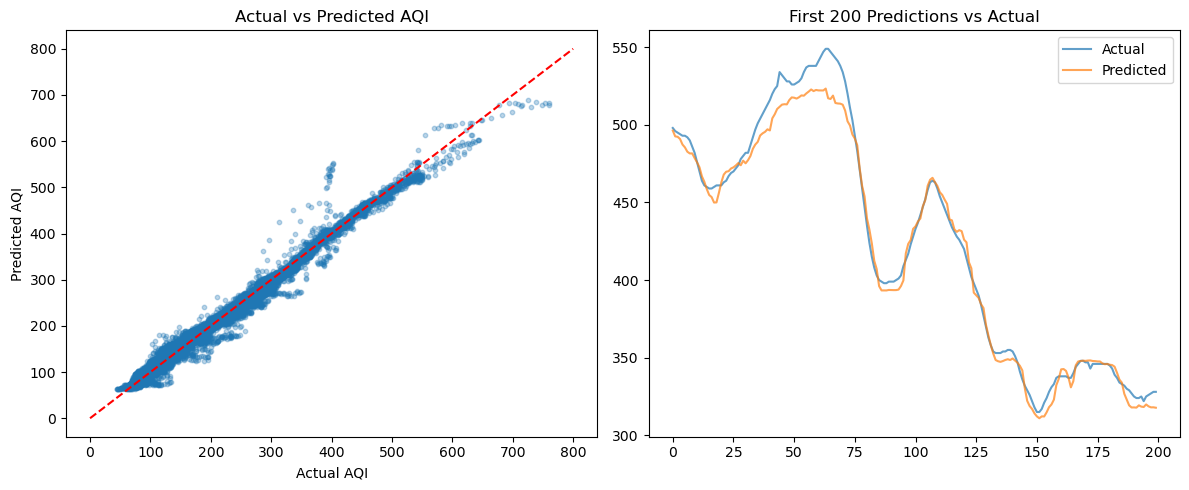

In [60]:
import matplotlib.pyplot as plt

# Plot actual vs predicted
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_test_v3, y_pred_v3, alpha=0.3, s=10)
plt.plot([0, 800], [0, 800], 'r--')
plt.xlabel('Actual AQI')
plt.ylabel('Predicted AQI')
plt.title('Actual vs Predicted AQI')

plt.subplot(1, 2, 2)
# Plot first 200 predictions vs actual
plt.plot(y_test_v3.values[:200], label='Actual', alpha=0.7)
plt.plot(y_pred_v3[:200], label='Predicted', alpha=0.7)
plt.legend()
plt.title('First 200 Predictions vs Actual')

plt.tight_layout()
plt.show()


In [61]:
import joblib

joblib.dump(rf_model_v3, 'delhi_aqi_model.pkl')
joblib.dump(feature_cols_v3, 'feature_cols.pkl')

print("✅ Model saved!")
print(f"Features used: {len(feature_cols_v3)}")

✅ Model saved!
Features used: 52


In [62]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Use all rows for clustering (not just AQI known rows)
cluster_features = ['pm25', 'pm10', 'no2', 'co', 'o3', 
                    'hour', 'month', 'is_weekend',
                    'temperature_2m', 'wind_speed_10m', 
                    'relative_humidity_2m']

df_cluster = df_wide[cluster_features].dropna().copy()

# Scale the features
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_cluster)

print(f"Clustering data shape: {df_cluster.shape}")
print(f"Features: {cluster_features}")

Clustering data shape: (59782, 11)
Features: ['pm25', 'pm10', 'no2', 'co', 'o3', 'hour', 'month', 'is_weekend', 'temperature_2m', 'wind_speed_10m', 'relative_humidity_2m']


k=2: inertia=543618
k=3: inertia=488891
k=4: inertia=443740
k=5: inertia=410639
k=6: inertia=387226
k=7: inertia=367383
k=8: inertia=351114
k=9: inertia=337998
k=10: inertia=324856


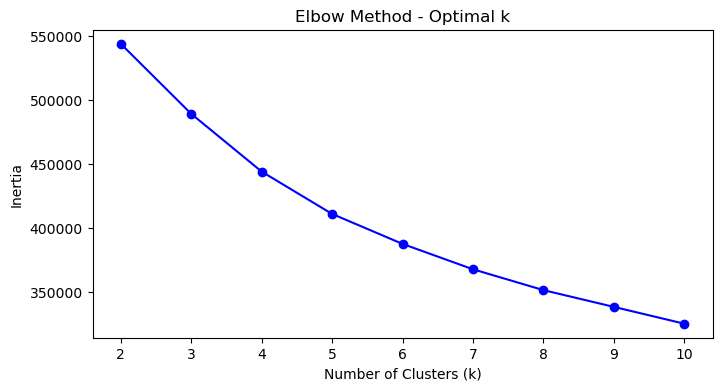

In [63]:
inertias = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    inertias.append(kmeans.inertia_)
    print(f"k={k}: inertia={kmeans.inertia_:.0f}")

plt.figure(figsize=(8, 4))
plt.plot(k_range, inertias, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method - Optimal k')
plt.savefig('elbow_plot.png', dpi=150)
plt.show()

In [64]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_wide_clean = df_wide.dropna(subset=cluster_features).copy()
df_wide_clean['cluster'] = kmeans.fit_predict(df_scaled)

print(df_wide_clean['cluster'].value_counts())
print("\nCluster pollution profiles:")
print(df_wide_clean.groupby('cluster')[['pm25', 'pm10', 'no2', 'co', 'o3']].mean().round(1))

cluster
1    17618
0    16367
3    15183
2    10614
Name: count, dtype: int64

Cluster pollution profiles:
          pm25   pm10   no2   co    o3
cluster                               
0         79.3  202.9  46.4  1.8  53.6
1         55.2  148.2  37.4  1.0  46.4
2        234.8  394.0  77.6  2.3  61.4
3        115.2  208.3  43.5  2.3  37.1


In [65]:
cluster_names = {0: 'Moderate', 1: 'Clean', 2: 'Severe', 3: 'High'}
df_wide_clean['pollution_category'] = df_wide_clean['cluster'].map(cluster_names)

print(df_wide_clean['pollution_category'].value_counts())
print("\nSeason distribution per cluster:")
print(pd.crosstab(df_wide_clean['pollution_category'], df_wide_clean['is_winter']))

pollution_category
Clean       17618
Moderate    16367
High        15183
Severe      10614
Name: count, dtype: int64

Season distribution per cluster:
is_winter               0     1
pollution_category             
Clean               17359   259
High                 5631  9552
Moderate            15608   759
Severe               5695  4919


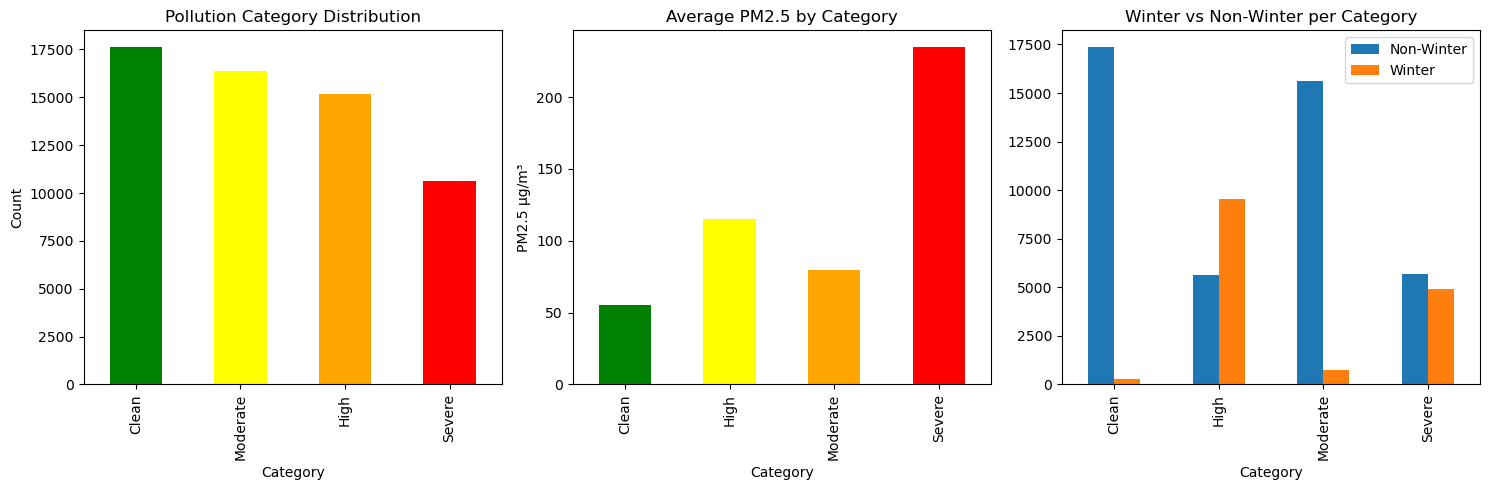

✅ Plot saved!


In [67]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot 1 - Cluster sizes
df_wide_clean['pollution_category'].value_counts().plot(
    kind='bar', ax=axes[0], color=['green', 'yellow', 'orange', 'red']
)
axes[0].set_title('Pollution Category Distribution')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Count')

# Plot 2 - PM2.5 by cluster
df_wide_clean.groupby('pollution_category')['pm25'].mean().plot(
    kind='bar', ax=axes[1], color=['green', 'yellow', 'orange', 'red']
)
axes[1].set_title('Average PM2.5 by Category')
axes[1].set_xlabel('Category')
axes[1].set_ylabel('PM2.5 µg/m³')

# Plot 3 - Winter vs non winter per cluster
pd.crosstab(df_wide_clean['pollution_category'], 
            df_wide_clean['is_winter']).plot(
    kind='bar', ax=axes[2]
)
axes[2].set_title('Winter vs Non-Winter per Category')
axes[2].set_xlabel('Category')
axes[2].legend(['Non-Winter', 'Winter'])

plt.tight_layout()
plt.savefig('clustering_results.png', dpi=150)
plt.show()
print("✅ Plot saved!")

In [68]:
print("Season distribution per cluster:")
print(pd.crosstab(df_wide_clean['pollution_category'], df_wide_clean['is_winter'], 
                  colnames=['is_winter'], rownames=['category']))

print("\nMonsoon distribution per cluster:")
print(pd.crosstab(df_wide_clean['pollution_category'], df_wide_clean['is_monsoon']))

print("\nStubble season distribution per cluster:")
print(pd.crosstab(df_wide_clean['pollution_category'], df_wide_clean['is_stubble_season']))

print("\nSummer distribution per cluster:")
print(pd.crosstab(df_wide_clean['pollution_category'], df_wide_clean['is_summer']))

Season distribution per cluster:
is_winter      0     1
category              
Clean      17359   259
High        5631  9552
Moderate   15608   759
Severe      5695  4919

Monsoon distribution per cluster:
is_monsoon              0      1
pollution_category              
Clean                2593  15025
High                15178      5
Moderate            16213    154
Severe              10460    154

Stubble season distribution per cluster:
is_stubble_season       0     1
pollution_category             
Clean               15530  2088
High                15179     4
Moderate            16367     0
Severe               5386  5228

Summer distribution per cluster:
is_summer               0      1
pollution_category              
Clean               17372    246
High                 9561   5622
Moderate              913  15454
Severe              10301    313


In [69]:
df_wide_clean.to_csv("delhi_clustered.csv", index=False)
joblib.dump(kmeans, 'kmeans_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
print("✅ Clustering results saved!")

✅ Clustering results saved!


In [70]:
!pip install streamlit